In [1]:
# Домашнее задание HW08-09
# PyTorch MLP: регуляризация и оптимизация обучения
    
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path
import time
from collections import defaultdict

# Настройка визуализации
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Создаём необходимые папки
os.makedirs("artifacts/figures", exist_ok=True)

In [2]:

# =============================================================================
# 1. Импорты, seed и устройство
# =============================================================================

def set_seed(seed=42):
    """Фиксация seed для воспроизводимости"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

# Определяем устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cpu


In [3]:
# =============================================================================
# 2. Данные и DataLoader
# =============================================================================

# Трансформации для CIFAR10 (RGB изображения 32x32)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Нормализация для 3 каналов (R,G,B)
])

# Загрузка данных CIFAR10
train_dataset_full = datasets.CIFAR10(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

# Название датасета
DATASET_NAME = "CIFAR10"
print(f"Используем датасет: {DATASET_NAME}")
print(f"Классы: {train_dataset_full.classes}")

# Разделение train на train/val (80/20)
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

train_dataset, val_dataset = random_split(
    train_dataset_full, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Размер обучающей выборки: {len(train_dataset)}")
print(f"Размер валидационной выборки: {len(val_dataset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")
print(f"Количество классов: {len(train_dataset_full.classes)}")

# DataLoader'ы
BATCH_SIZE = 128  # Можно уменьшить до 64, если память не хватает

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Проверка размеров батча
x_batch, y_batch = next(iter(train_loader))
print(f"\nРазмер батча - вход: {x_batch.shape}, выход: {y_batch.shape}")
print(f"Диапазон значений входных данных: [{x_batch.min():.2f}, {x_batch.max():.2f}]")

100.0%
c:\Users\zsedc\ml_Yakunicheva\myenv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Используем датасет: CIFAR10
Классы: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Размер обучающей выборки: 40000
Размер валидационной выборки: 10000
Размер тестовой выборки: 10000
Количество классов: 10

Размер батча - вход: torch.Size([128, 3, 32, 32]), выход: torch.Size([128])
Диапазон значений входных данных: [-1.00, 1.00]


In [4]:

# =============================================================================
# 3. Модель MLP
# =============================================================================

class MLP(nn.Module):
    """Многослойный перцептрон с опциональными Dropout и BatchNorm"""
    
    def __init__(self, input_size=28*28, hidden_sizes=[256, 128], num_classes=10,
                 dropout_rate=0.0, use_batchnorm=False):
        super().__init__()
        
        layers = []
        prev_size = input_size
        
        for i, hidden_size in enumerate(hidden_sizes):
            layers.append(nn.Linear(prev_size, hidden_size))
            
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            
            layers.append(nn.ReLU())
            
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            
            prev_size = hidden_size
        
        # Выходной слой
        layers.append(nn.Linear(prev_size, num_classes))
        
        self.net = nn.Sequential(*layers)
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.dropout_rate = dropout_rate
        self.use_batchnorm = use_batchnorm
    
    def forward(self, x):
        # Flatten: из (batch, 1, 28, 28) в (batch, 784)
        x = x.view(x.size(0), -1)
        return self.net(x)
    
    def get_config(self):
        """Возвращает конфигурацию модели"""
        return {
            "input_size": self.input_size,
            "hidden_sizes": self.hidden_sizes,
            "num_classes": 10,
            "dropout_rate": self.dropout_rate,
            "use_batchnorm": self.use_batchnorm
        }


In [5]:
# =============================================================================
# 4. Циклы обучения и оценки
# =============================================================================

def train_epoch(model, loader, criterion, optimizer, device):
    """Одна эпоха обучения"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * x.size(0)
        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
    
    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

def evaluate(model, loader, criterion, device):
    """Оценка модели на валидации/тесте"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            
            total_loss += loss.item() * x.size(0)
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
    
    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

def train_model(model, train_loader, val_loader, criterion, optimizer, 
                epochs, device, early_stopping_patience=None):
    """Полный цикл обучения с опциональным ранней остановкой"""
    
    history = defaultdict(list)
    best_val_acc = 0
    best_epoch = 0
    patience_counter = 0
    
    for epoch in range(epochs):
        # Обучение
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Валидация
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        # Логирование
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
        # Early Stopping
        if early_stopping_patience:
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_epoch = epoch
                patience_counter = 0
                # Сохраняем лучшую модель
                torch.save(model.state_dict(), 'artifacts/best_model_temp.pt')
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    print(f"\nEarly stopping на эпохе {epoch+1}")
                    print(f"Лучшая валидационная точность: {best_val_acc:.4f} на эпохе {best_epoch+1}")
                    break
    
    # Загружаем лучшую модель
    if early_stopping_patience and os.path.exists('artifacts/best_model_temp.pt'):
        model.load_state_dict(torch.load('artifacts/best_model_temp.pt'))
        os.remove('artifacts/best_model_temp.pt')
    
    return model, history


In [6]:
def run_experiment(experiment_id, model_config, optimizer_config, 
                   epochs=20, early_stopping_patience=None):
    """Запуск одного эксперимента и возврат результатов"""
    
    print(f"\n{'='*60}")
    print(f"ЭКСПЕРИМЕНТ {experiment_id}")
    print(f"{'='*60}")
    
    # Создаём модель
    model = MLP(**model_config).to(device)
    print(f"Модель: {model_config}")
    
    # Создаём оптимизатор
    if optimizer_config['name'] == 'Adam':
        optimizer = optim.Adam(
            model.parameters(), 
            lr=optimizer_config['lr'],
            weight_decay=optimizer_config.get('weight_decay', 0)
        )
    elif optimizer_config['name'] == 'SGD':
        optimizer = optim.SGD(
            model.parameters(), 
            lr=optimizer_config['lr'],
            momentum=optimizer_config.get('momentum', 0),
            weight_decay=optimizer_config.get('weight_decay', 0)
        )
    
    criterion = nn.CrossEntropyLoss()
    
    # Обучение
    start_time = time.time()
    model, history = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        epochs=epochs, device=device,
        early_stopping_patience=early_stopping_patience
    )
    training_time = time.time() - start_time
    
    # Финальная оценка на валидации
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    
    # Сохраняем результаты
    result = {
        'experiment_id': experiment_id,
        'dataset': DATASET_NAME,
        'seed': SEED,
        'model_summary': str(model_config),  # оставляем как строку
        'optimizer': optimizer_config['name'],
        'lr': optimizer_config['lr'],
        'momentum': optimizer_config.get('momentum', 0),
        'weight_decay': optimizer_config.get('weight_decay', 0),
        'epochs_trained': len(history['train_loss']),
        'best_val_accuracy': val_acc,
        'best_val_loss': val_loss,
        'training_time': training_time,
        'history': history,
        'model': model  # ← ТОЛЬКО ЭТУ СТРОКУ ДОБАВЛЯЕМ
    }
    
    return result

In [7]:
# =============================================================================
# 6. Эксперименты
# =============================================================================

results = []

# Базовая архитектура для всех экспериментов
base_model_config = {
    'input_size': 32*32*3,  # 3072 для CIFAR10
    'hidden_sizes': [512, 256],  
    'num_classes': 10,
    'dropout_rate': 0.0,
    'use_batchnorm': False
}


In [8]:
# =============================================================================
# Часть A (S08): регуляризация
# =============================================================================

print("\n" + "="*60)
print("ЧАСТЬ A: РЕГУЛЯРИЗАЦИЯ")
print("="*60)

# E1 (base) - без регуляризации
config_e1 = base_model_config.copy()
result_e1 = run_experiment(
    'E1', 
    config_e1,
    {'name': 'Adam', 'lr': 0.001},
    epochs=15
)
results.append(result_e1)

# E2 (Dropout)
config_e2 = base_model_config.copy()
config_e2['dropout_rate'] = 0.3
result_e2 = run_experiment(
    'E2',
    config_e2,
    {'name': 'Adam', 'lr': 0.001},
    epochs=15
)
results.append(result_e2)

# E3 (BatchNorm)
config_e3 = base_model_config.copy()
config_e3['use_batchnorm'] = True
result_e3 = run_experiment(
    'E3',
    config_e3,
    {'name': 'Adam', 'lr': 0.001},
    epochs=15
)
results.append(result_e3)

# Выбираем лучший из E2/E3 для E4
best_val_acc = 0
best_e4_config = None
best_e4_id = None

for r in [result_e2, result_e3]:
    if r['best_val_accuracy'] > best_val_acc:
        best_val_acc = r['best_val_accuracy']
        best_e4_config = r['model_summary']
        best_e4_id = r['experiment_id']

print(f"\nЛучший эксперимент для E4: {best_e4_id} с валидационной точностью {best_val_acc:.4f}")

# E4 (EarlyStopping) - лучший из E2/E3 с ранней остановкой
config_e4 = eval(best_e4_config)  # Преобразуем строку обратно в словарь
result_e4 = run_experiment(
    'E4',
    config_e4,
    {'name': 'Adam', 'lr': 0.001},
    epochs=30,
    early_stopping_patience=5
)
results.append(result_e4)


ЧАСТЬ A: РЕГУЛЯРИЗАЦИЯ

ЭКСПЕРИМЕНТ E1
Модель: {'input_size': 3072, 'hidden_sizes': [512, 256], 'num_classes': 10, 'dropout_rate': 0.0, 'use_batchnorm': False}
Epoch 1/15 | Train Loss: 1.6615 | Train Acc: 0.4101 | Val Loss: 1.5566 | Val Acc: 0.4514
Epoch 2/15 | Train Loss: 1.4437 | Train Acc: 0.4902 | Val Loss: 1.4573 | Val Acc: 0.4789
Epoch 3/15 | Train Loss: 1.3229 | Train Acc: 0.5316 | Val Loss: 1.4085 | Val Acc: 0.5085
Epoch 4/15 | Train Loss: 1.2223 | Train Acc: 0.5686 | Val Loss: 1.3831 | Val Acc: 0.5234
Epoch 5/15 | Train Loss: 1.1320 | Train Acc: 0.5979 | Val Loss: 1.4200 | Val Acc: 0.5202
Epoch 6/15 | Train Loss: 1.0457 | Train Acc: 0.6306 | Val Loss: 1.3795 | Val Acc: 0.5331
Epoch 7/15 | Train Loss: 0.9569 | Train Acc: 0.6618 | Val Loss: 1.4271 | Val Acc: 0.5299
Epoch 8/15 | Train Loss: 0.8752 | Train Acc: 0.6892 | Val Loss: 1.4447 | Val Acc: 0.5338
Epoch 9/15 | Train Loss: 0.7950 | Train Acc: 0.7179 | Val Loss: 1.5450 | Val Acc: 0.5287
Epoch 10/15 | Train Loss: 0.7120 | Tra

In [9]:
# =============================================================================
# Часть B (S09): LR, оптимизаторы, weight decay
# =============================================================================

print("\n" + "="*60)
print("ЧАСТЬ B: ОПТИМИЗАЦИЯ")
print("="*60)

# Используем ту же архитектуру, что и в E4
config_b = eval(best_e4_config)

# O1: LR слишком большой
result_o1 = run_experiment(
    'O1',
    config_b,
    {'name': 'Adam', 'lr': 0.1},
    epochs=8
)
results.append(result_o1)

# O2: LR слишком маленький
result_o2 = run_experiment(
    'O2',
    config_b,
    {'name': 'Adam', 'lr': 0.00001},
    epochs=8
)
results.append(result_o2)

# O3: SGD+momentum + weight decay
result_o3 = run_experiment(
    'O3',
    config_b,
    {'name': 'SGD', 'lr': 0.01, 'momentum': 0.9, 'weight_decay': 0.0001},
    epochs=12
)
results.append(result_o3)




ЧАСТЬ B: ОПТИМИЗАЦИЯ

ЭКСПЕРИМЕНТ O1
Модель: {'input_size': 3072, 'hidden_sizes': [512, 256], 'num_classes': 10, 'dropout_rate': 0.0, 'use_batchnorm': True}
Epoch 1/8 | Train Loss: 1.9221 | Train Acc: 0.3295 | Val Loss: 1.7559 | Val Acc: 0.3705
Epoch 2/8 | Train Loss: 1.6421 | Train Acc: 0.4085 | Val Loss: 1.6304 | Val Acc: 0.4276
Epoch 3/8 | Train Loss: 1.5531 | Train Acc: 0.4447 | Val Loss: 1.5444 | Val Acc: 0.4449
Epoch 4/8 | Train Loss: 1.5000 | Train Acc: 0.4657 | Val Loss: 1.5621 | Val Acc: 0.4527
Epoch 5/8 | Train Loss: 1.4450 | Train Acc: 0.4862 | Val Loss: 1.4862 | Val Acc: 0.4664
Epoch 6/8 | Train Loss: 1.4064 | Train Acc: 0.4987 | Val Loss: 1.5106 | Val Acc: 0.4681
Epoch 7/8 | Train Loss: 1.3653 | Train Acc: 0.5140 | Val Loss: 1.4977 | Val Acc: 0.4834
Epoch 8/8 | Train Loss: 1.3311 | Train Acc: 0.5280 | Val Loss: 1.5133 | Val Acc: 0.4816

ЭКСПЕРИМЕНТ O2
Модель: {'input_size': 3072, 'hidden_sizes': [512, 256], 'num_classes': 10, 'dropout_rate': 0.0, 'use_batchnorm': True}
Ep

In [10]:
# =============================================================================
# 7. Сохранение результатов
# =============================================================================

# Создаём DataFrame с результатами
runs_df = pd.DataFrame([{
    'experiment_id': r['experiment_id'],
    'dataset': r['dataset'],
    'seed': r['seed'],
    'model_summary': r['model_summary'],
    'optimizer': r['optimizer'],
    'lr': r['lr'],
    'momentum': r['momentum'],
    'weight_decay': r['weight_decay'],
    'epochs_trained': r['epochs_trained'],
    'best_val_accuracy': r['best_val_accuracy'],
    'best_val_loss': r['best_val_loss'],
    'training_time': r['training_time']
} for r in results])

# Сохраняем в CSV
runs_df.to_csv('artifacts/runs.csv', index=False)
print("\nРезультаты сохранены в artifacts/runs.csv")
print(runs_df.to_string())

# Сохраняем лучшую модель (E4)
best_model_e4 = None
for r in results:
    if r['experiment_id'] == 'E4':
        best_model_e4 = r['model']  # ← ТЕПЕРЬ 'model' ЕСТЬ В СЛОВАРЕ
        best_val_acc = r['best_val_accuracy']
        best_model_summary = r['model_summary']
        break

if best_model_e4:
    # Сохраняем state_dict модели
    torch.save(best_model_e4.state_dict(), 'artifacts/best_model.pt')
    print(f"\n✅ Лучшая модель сохранена в artifacts/best_model.pt")
    print(f"   Валидационная точность: {best_val_acc:.4f}")
    
    # Сохраняем конфиг лучшей модели
    best_config = {
        'experiment_id': 'E4',
        'model_config': best_model_summary,
        'optimizer_config': {'name': 'Adam', 'lr': 0.001},
        'dataset': DATASET_NAME,
        'seed': SEED,
        'best_val_accuracy': float(best_val_acc)
    }
    
    with open('artifacts/best_config.json', 'w', encoding='utf-8') as f:
        json.dump(best_config, f, indent=4, ensure_ascii=False)
    print("✅ Конфиг лучшей модели сохранён в artifacts/best_config.json")
    
    # Финальная оценка на тесте
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc = evaluate(best_model_e4, test_loader, criterion, device)
    print(f"\n📊 Финальная оценка на тестовой выборке:")
    print(f"   Test Loss: {test_loss:.4f}")
    print(f"   Test Accuracy: {test_acc:.4f}")
else:
    print("❌ Модель E4 не найдена в результатах!")


Результаты сохранены в artifacts/runs.csv
  experiment_id  dataset  seed                                                                                                     model_summary optimizer       lr  momentum  weight_decay  epochs_trained  best_val_accuracy  best_val_loss  training_time
0            E1  CIFAR10    42  {'input_size': 3072, 'hidden_sizes': [512, 256], 'num_classes': 10, 'dropout_rate': 0.0, 'use_batchnorm': False}      Adam  0.00100       0.0        0.0000              15             0.5314       2.049873     136.222248
1            E2  CIFAR10    42  {'input_size': 3072, 'hidden_sizes': [512, 256], 'num_classes': 10, 'dropout_rate': 0.3, 'use_batchnorm': False}      Adam  0.00100       0.0        0.0000              15             0.5380       1.327146     124.384412
2            E3  CIFAR10    42   {'input_size': 3072, 'hidden_sizes': [512, 256], 'num_classes': 10, 'dropout_rate': 0.0, 'use_batchnorm': True}      Adam  0.00100       0.0        0.0000           

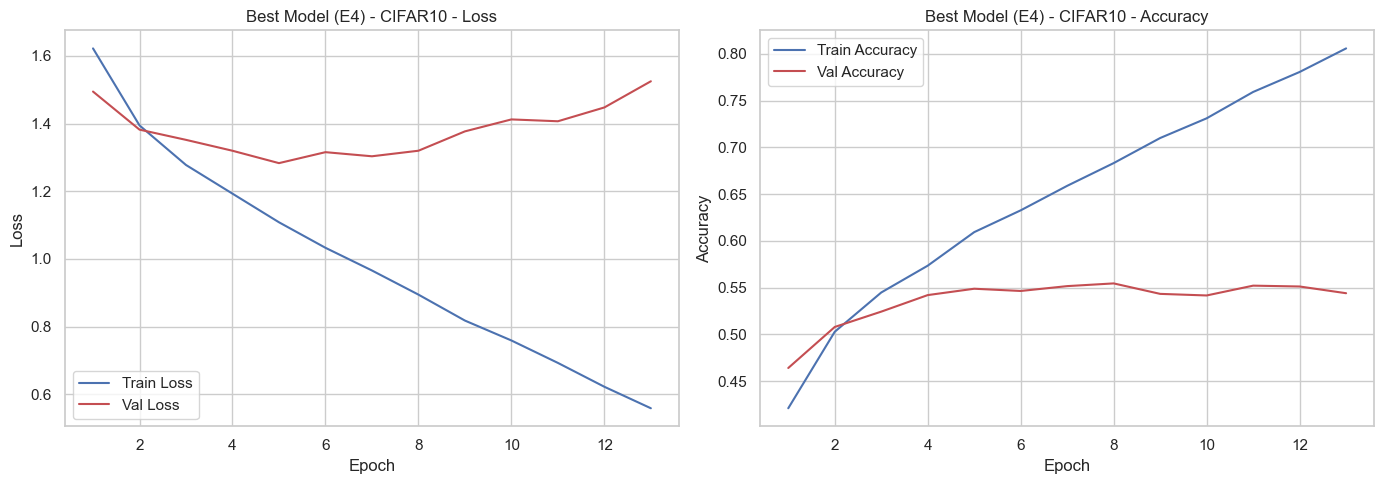

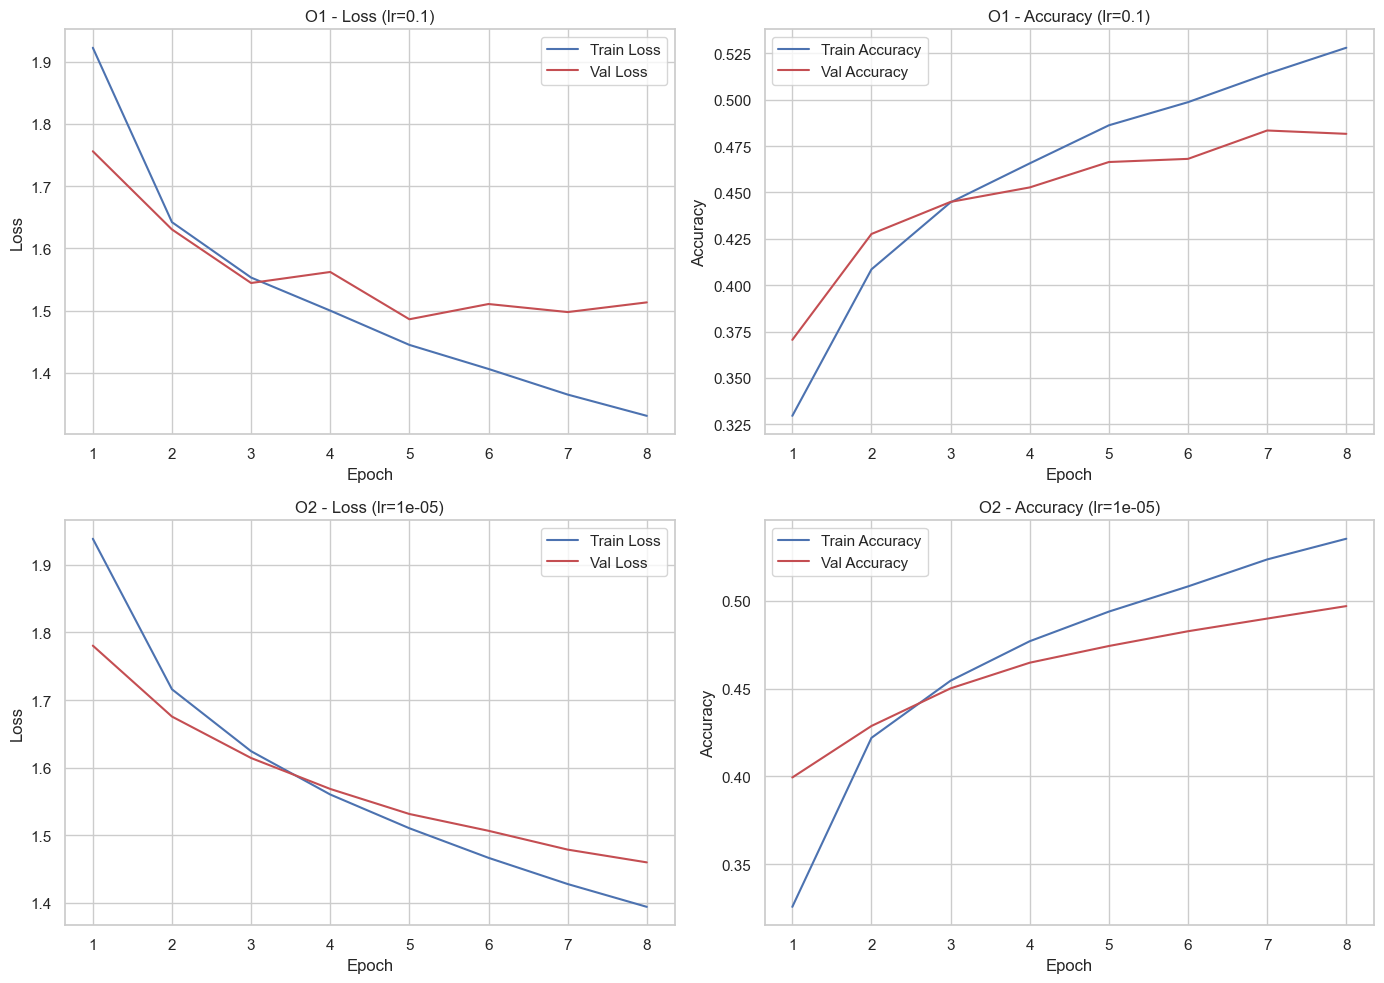

Графики сохранены в artifacts/figures/

ФИНАЛЬНАЯ ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ
Test Loss: 1.3182
Test Accuracy: 0.5489

ЭКСПЕРИМЕНТ ЗАВЕРШЁН


In [11]:
# =============================================================================
# 8. Визуализация результатов
# =============================================================================

def plot_training_history(history, title, save_path=None):
    """Построение графиков обучения"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # График потерь
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(True)
    
    # График точности
    ax2.plot(epochs, history['train_acc'], 'b-', label='Train Accuracy')
    ax2.plot(epochs, history['val_acc'], 'r-', label='Val Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

# График для лучшего прогона (E4)
for r in results:
    if r['experiment_id'] == 'E4':
        plot_training_history(
            r['history'], 
            f'Best Model (E4) - {DATASET_NAME}',
            save_path='artifacts/figures/curves_best.png'
        )
        break

# График для плохих LR (O1, O2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, exp_id in enumerate(['O1', 'O2']):
    for r in results:
        if r['experiment_id'] == exp_id:
            history = r['history']
            epochs = range(1, len(history['train_loss']) + 1)
            
            # Loss
            axes[i, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss')
            axes[i, 0].plot(epochs, history['val_loss'], 'r-', label='Val Loss')
            axes[i, 0].set_xlabel('Epoch')
            axes[i, 0].set_ylabel('Loss')
            axes[i, 0].set_title(f'{exp_id} - Loss (lr={r["lr"]})')
            axes[i, 0].legend()
            axes[i, 0].grid(True)
            
            # Accuracy
            axes[i, 1].plot(epochs, history['train_acc'], 'b-', label='Train Accuracy')
            axes[i, 1].plot(epochs, history['val_acc'], 'r-', label='Val Accuracy')
            axes[i, 1].set_xlabel('Epoch')
            axes[i, 1].set_ylabel('Accuracy')
            axes[i, 1].set_title(f'{exp_id} - Accuracy (lr={r["lr"]})')
            axes[i, 1].legend()
            axes[i, 1].grid(True)
            
            break

plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png', dpi=300, bbox_inches='tight')
plt.show()
print("Графики сохранены в artifacts/figures/")

# =============================================================================
# 9. Финальная оценка лучшей модели на тестовой выборке
# =============================================================================

print("\n" + "="*60)
print("ФИНАЛЬНАЯ ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*60)

if best_model_e4:
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc = evaluate(best_model_e4, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    
    # Сохраняем тестовую точность в конфиг
    best_config['test_accuracy'] = float(test_acc)
    with open('artifacts/best_config.json', 'w') as f:
        json.dump(best_config, f, indent=4)

print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ ЗАВЕРШЁН")
print("="*60)                                  